### Setup Imports & plotting configuration

In [3]:
# Deterministic domain and grid generators
import numpy as np
import matplotlib.pyplot as plt
# matplotlib: It is a python 2D plotting library which produces publication-quality figures in a variety of hardcopy formats and interactive environments across platforms.
# import matplotlib.pyplot:- This line of code imports the Pyplot module from the Matplotlib library in Python, which is the standard tool used for creating data visualizations, plots, and charts.
# as plt: Creates a standard shorthand alias (plt) so you don't have to type out the full module name every time you want to use a plotting function.

# Apply clean visualization style
plt.style.use('seaborn-v0_8_whitegrid' if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default')
# plt.style.use(...): A Matplotlib function used to apply a predefined style template, changing aspects like colors, background grids, line thickness, and font styles across all subsequent plots in your script.
# seaborn-v0_8_whitegrid : A clean white grid style inspired by seaborn's whitegrid theme.
# if 'seaborn-v0_8_whitegrid' in plt.style.available else 'default': A Python conditional (ternary) check. It ensures your code won't crash if a particular version of Matplotlib doesn't have that exact style name available, falling back to the standard 'default' style instead.

plt.rcParams["figure.dpi"] = 100
# rc = runtime configuration
# plt.rcParams: A built-in dictionary-like object in Matplotlib used to manage global runtime configuration settings. Changing values here affects every plot you create afterward in your script.
# "figure.dpi": The specific configuration parameter for Dots Per Inch (DPI), which determines how many pixels make up an inch of your plot image.
# = 100: Sets the resolution to 100 DPI.

### 1. Linear Spacing ('np.linespace')

### Overview & Purpose
- Generates $N$ evenly spaced numbers over a specified closed interval $[a, b]$. 
- It is primarily used for constructing independent variable domains ($x$-axis), plotting smooth continuous curves, and evaluating function values over regular intervals.

### Mathematical Formula
The step size $h$ between consecutive elements is calculated automatically as:

$$h = \frac{b - a}{N - 1}$$

The $i$-th element in the generated array is given by:

$$x_i = a + i \cdot h \quad \text{for } i = 0, 1, 2, \dots, N - 1$$

**Pronunciation & Symbol Guide:**
* $a$: Start of interval (scalar value).
* $b$: End of interval (scalar value).
* $N$: Total number of samples to generate (*N*).
* $h$: Step size / increment delta (*h*).
* $x_i$: The $i$-th element (*x sub i*).

### Parameters
* `start`: `float` — The starting value of the sequence ($a$).
* `stop`: `float` — The end value of the sequence ($b$).
* `num`: `int`, default=`50` — Number of samples to generate ($N$). Must be non-negative.
* `endpoint`: `bool`, default=`True` — If `True`, `stop` is the last sample. Otherwise, it is excluded.
* `retstep`: `bool`, default=`False` — If `True`, returns `(samples, step)`, where `step` is the calculated spacing $h$. If set to True, NumPy doesn't just return the array of numbers; it returns a tuple containing both the array and the calculated step size $h$ (samples, step).
* `dtype`: `dtype`, optional — The type of the output array.


Linear space array: [ 0.          0.71428571  1.42857143  2.14285714  2.85714286  3.57142857
  4.28571429  5.          5.71428571  6.42857143  7.14285714  7.85714286
  8.57142857  9.28571429 10.        ]
Step size: 0.7142857142857143


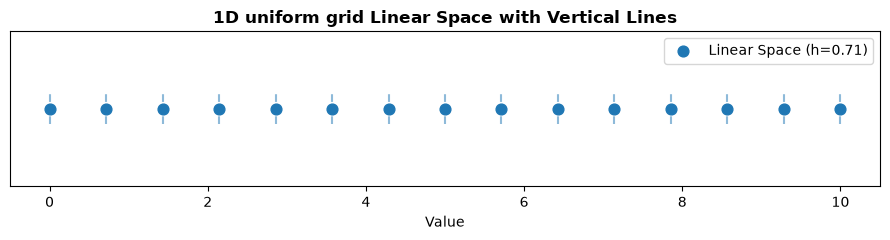

In [ ]:
# retstep = True to return the step size along with the generated array(sample, step_size)
x_linear, step_size = np.linspace(start=0.0, stop=10.0, num=15, retstep=True)
print("Linear space array:", x_linear)
print("Step size:", step_size)
# Plot the linear space array
plt.figure(figsize=(9, 2.5)) # figsize=(9, 2.5) is the width and height of the figure in inches.
# By default, Matplotlib creates square-ish figures (usually around 6.4 X 4.8 inches. Specifying a custom figsize lets you control the aspect ratio and shape of your graph.

# What is a scatter plot?
# A scatter plot is a type of data visualization that uses individual dots (markers) to represent values for two different numeric variables.One variable is plotted along the $x$-axis (horizontal), and the other is plotted along the $y$-axis (vertical).

# scatter plot parameters detailed:
# s=60 : size of the scatter plot markers
# color='#1f77b4' : color of the scatter plot markers
# zorder=3 : sets the drawing order of the scatter plot markers (higher values are drawn on top)
# label=f'Linear Space (h={step_size:.2f})' : label for the scatter plot, showing the step size in the legend.

plt.scatter(x_linear, np.zeros_like(x_linear),color='#1f77b4',s=60,zorder=3,label=f'Linear Space (h={step_size:.2f})')
# np.zeros_like(x_linear) (The y-coordinates)A NumPy function that creates an array of zeros (0.0) with the exact same length and data type as x_linear. Because every y-value is 0, all the dots will line up flatly along the horizontal x-axis (acting like a visual number line).

# what is vlines?
# plt.vlines(...)A Matplotlib function designed specifically to draw vertical lines at given x positions, spanning from a specified minimum y-value to a maximum y-value.
# vlines parameters detailed:
# x_linear : x-coordinates of the vertical lines
# ymin/ymax : vertical range of drop lines
# alpha=0.5 : transparency level of the vertical lines (0.0 fully transparent, 1.0 fully opaque)
# linestyles='--' : style of the vertical lines (dashed in this case)
plt.vlines(x_linear, ymin=-0.1, ymax=0.1, color='#1f77b4', alpha=0.5, linestyles='--')

plt.title("1D uniform grid Linear Space with Vertical Lines",fontsize=12, fontweight='bold')
plt.xlabel("Value")
plt.yticks([])  # Hide y-axis ticks since all points lie on the same horizontal line (y=0)
plt.ylim(-0.5,0.5) # Set the vertical limits to provide some space around the horizontal line (y=0)
plt.legend(loc='upper right') 
plt.tight_layout()  # Adjust the layout to prevent overlapping elements
plt.show()


## 2. Logarithmic Spacing (`np.logspace`)

### Overview & Purpose
- Generates numbers spaced evenly on a logarithmic scale. 
- It is widely used in machine learning for defining hyperparameter search grids (e.g., learning rates $\eta$, regularization strength $\alpha$) spanning multiple orders of magnitude.

### Mathematical Formula
Given base $k$ (default $10$), starting exponent $a$, and ending exponent $b$, the values are generated as:

$$y_i = k^{x_i} \quad \text{where } x_i = a + i \cdot \left(\frac{b - a}{N - 1}\right)$$

$$y_i = 10^{\text{linspace}(a, b, N)_i}$$

**Pronunciation & Symbol Guide:**
* $a$: Starting power of the base (*start power*).
* $b$: Ending power of the base (*stop power*).
* $k$: Logarithmic base, typically $10$ (*base k*).
* $y_i$: The $i$-th element on the exponential scale (*y sub i*).

### Parameters
* `start`: `float` — `base ** start` is the starting value of the sequence.
* `stop`: `float` — `base ** stop` is the final value of the sequence (unless `endpoint=False`).
* `num`: `int`, default=`50` — Number of samples to generate.
* `endpoint`: `bool`, default=`True` — Whether to include `base ** stop` as the last value.
* `base`: `float`, default=`10.0` — The base of the log space.
* `dtype`: `dtype`, optional — The type of the output array.

Logarithmic space array: [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]
Generated Hyperparameters learning_rates
learning rates ['0.000010', '0.000100', '0.001000', '0.010000', '0.100000', '1.000000', '10.000000']


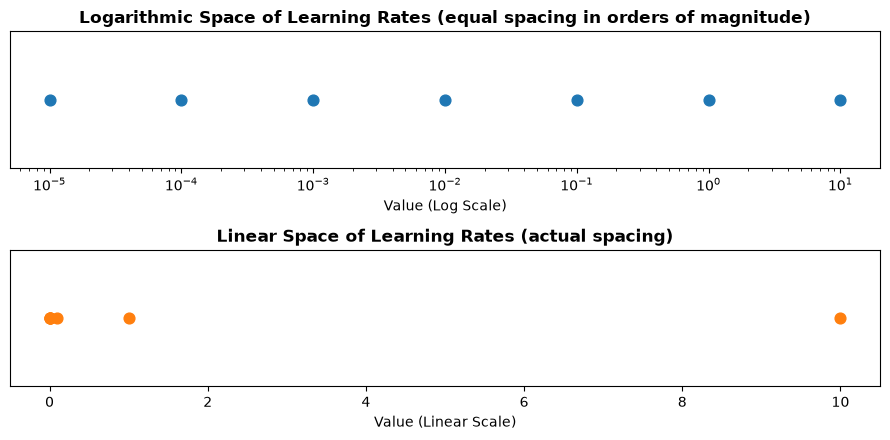

In [12]:
# Generates 7 points from 10^-5(0.00001) to 10^1 (10.0) using logarithmic spacing
learning_rates = np.logspace(start=-5, stop=1, num=7, base=10)
print("Logarithmic space array:", learning_rates)
print("Generated Hyperparameters learning_rates")
# for i, lr in enumerate(learning_rates):
#     print(f"learning_rate[{i}] = {lr:.6f}")
# print()
print("learning rates",[f"{lr:.6f}" for lr in learning_rates])

# subplot parameters detailed:
# 2,1 : 2 rows, 1 column of subplots
# figsize=(9,4.5) : width and height of the figure in inches
# (ax1, ax2) are the axes objects for the two subplots
fig,(ax1,ax2) = plt.subplots(2,1,figsize=(9,4.5))

# top plot : logarithmic scale visualization
ax1.scatter(learning_rates, np.zeros_like(learning_rates), color='#1f77b4', s=60, zorder=3)
ax1.set_xscale('log')
ax1.set_title("Logarithmic Space of Learning Rates (equal spacing in orders of magnitude)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Value (Log Scale)")
ax1.set_yticks([])  # Hide y-axis ticks since all points lie on the same horizontal line (y=0)

# bottom plot : linear scale visualization
ax2.scatter(learning_rates, np.zeros_like(learning_rates), color='#ff7f0e', s=60, zorder=3)
ax2.set_xscale('linear')
ax2.set_title("Linear Space of Learning Rates (actual spacing)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Value (Linear Scale)")
ax2.set_yticks([])  # Hide y-axis ticks since all points lie on the same horizontal line (y=0)

plt.tight_layout()  # Adjust the layout to prevent overlapping elements
plt.show()



## 3. Geometric Spacing (`np.geomspace`)

### Overview & Purpose
- Generates numbers spaced evenly on a logarithmic scale, but allows specifying the **actual start and end values directly** instead of specifying exponent powers. 
- Useful for geometric ratio progression sequences.

### Mathematical Formula
For start endpoint $p > 0$ and stop endpoint $q > 0$:

$$g_i = p \cdot \left(\frac{q}{p}\right)^{\frac{i}{N - 1}} \quad \text{for } i = 0, 1, 2, \dots, N - 1$$

The constant multiplicative common ratio $r$ between successive terms is:

$$r = \left(\frac{q}{p}\right)^{\frac{1}{N - 1}}$$

**Pronunciation & Symbol Guide:**
* $p$: Actual starting value ($p$, pronounced *p*).
* $q$: Actual ending value ($q$, pronounced *q*).
* $r$: Geometric common ratio (*r*).
* $g_i$: The $i$-th element in the geometric progression (*g sub i*).

### Parameters
* `start`: `float` — The starting value of the sequence ($p > 0$).
* `stop`: `float` — The end value of the sequence ($q > 0$).
* `num`: `int`, default=`50` — Number of samples to generate.
* `endpoint`: `bool`, default=`True` — Whether to include `stop` as the last value.
* `dtype`: `dtype`, optional — The type of the output array.

Geometric space array: [   1.            3.98107171   15.84893192   63.09573445  251.18864315
 1000.        ]
Common multiplicative ratio of geometric space array:  3.9811


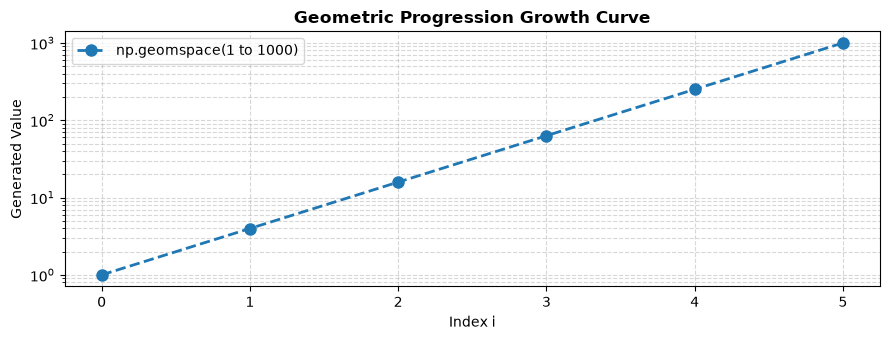

In [17]:
geom_grid = np.geomspace(start=1.0, stop=1000.0, num=6)
print("Geometric space array:", geom_grid)
print(f"Common multiplicative ratio of geometric space array: {geom_grid[1]/geom_grid[0] : .4f}")
# graphical visualization of geometric space
plt.figure(figsize=(9,3.5)) # Set the figure size for the plot in inches
# plot formatting parameters details:
# '0--' : combination of circle marker 'o' and dashed line '--'
# 'marker' : specifies the marker style for the data points
plt.plot(range(len(geom_grid)), geom_grid, 'o--', color='#1f77b4', linewidth=2,markersize=8, label="np.geomspace(1 to 1000)")
plt.title('Geometric Progression Growth Curve', fontsize=12, fontweight='bold')
plt.xlabel('Index i')
plt.ylabel('Generated Value')
plt.yscale('log')          # Logarithmic y-scale turns geometric curve into a straight line
plt.grid(True, which="both", ls ='--',alpha=0.5)
plt.legend() # Display the legend for the plot
plt.tight_layout()  # Adjust the layout to prevent overlapping elements
plt.show()

## 4. Step-Based Range (`np.arange`)

### Overview & Purpose
- Generates evenly spaced values within a half-open interval $[a, b)$ based on an explicit step size $h$. 
- Used for indexing arrays, generating discrete time steps, and creating fixed-increment integer or floating-point domain vectors.

### Mathematical Formula
Generates sequence $z_k$ until $z_k < b$:

$$z_k = a + k \cdot h \quad \text{where } k \in \mathbb{N}_0 \text{ such that } a + k \cdot h < b$$

**Pronunciation & Symbol Guide:**
* $a$: Start value (*a*).
* $b$: Upper bound limit (*b*, non-inclusive).
* $h$: Explicit step size / increment (*h* or *delta*).
* $k$: Step index integer (*k*).
* $\mathbb{N}_0$: Non-negative integers (*N sub zero*).

### Parameters
* `start`: `number`, optional — Start of interval. Defaults to `0`.
* `stop`: `number` — End of interval (excluded from array).
* `step`: `number`, optional — Spacing between values ($h$). Defaults to `1`.
* `dtype`: `dtype`, optional — Explicit output data type.

Time steps array: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]
Common difference of time steps array: 0.5
Total number of time steps: 10


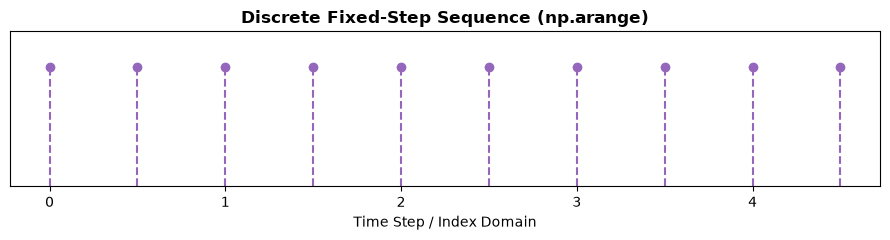

In [24]:
time_steps = np.arange(start=0.0, stop=5.0, step=0.5)
print("Time steps array:", time_steps)
print("Common difference of time steps array:", time_steps[1] - time_steps[0])
print("Total number of time steps:", len(time_steps))

# Graphical visualization of time steps
plt.figure(figsize=(9,2.5)) # Set the figure size for the plot in inches


# what is a stem plot:
# A stem plot is a type of plot that displays data points as vertical lines (stems) extending from a baseline, with markers at the tips of the stems. It is useful for visualizing discrete data points and their distribution along an axis.

# stem plote parameters details:
# 'linefmt = "C4--"' specifies the color(C4 = fourth color in the default color cycle (purple)) and line style for the stem lines
# color cycle definitions: C1 = blue, C2 = orange, C3 = green, C4 = purple, C5 = brown, C6 = pink, C7 = gray, C8 = olive, C9 = cyan
# 'markerfmt = "C4o"' specifies the color and marker style for the stem markers
# 'basefmt = " "' specifies the format for the baseline of the stem plot, here it is set to an empty string to hide the baseline
plt.stem(time_steps,np.ones_like(time_steps), linefmt='C4--', markerfmt='C4o',basefmt=" ")

plt.title('Discrete Fixed-Step Sequence (np.arange)', fontsize=12, fontweight='bold')
plt.xlabel('Time Step / Index Domain')
plt.yticks([])
plt.ylim(0, 1.3) # Set the y-axis limits to provide some space above the stems
plt.tight_layout()
plt.show()


## 5. Coordinate Grids (`np.meshgrid`)

### Overview & Purpose
- Constructs coordinate matrices from 1D coordinate vectors. 
- It converts 1D domain axes into 2D (or $N$-D) matrices representing spatial coordinates $(X, Y)$ across a grid. Essential for evaluating multivariate mathematical surfaces $z = f(x, y)$, rendering 3D loss landscapes, and spatial grid population.

### Mathematical Structure
Given 1D domain vectors $\mathbf{x} = [x_0, x_1, \dots, x_{M-1}]$ of length $M$ and $\mathbf{y} = [y_0, y_1, \dots, y_{N-1}]$ of length $N$:

$$\mathbf{X} = \begin{bmatrix} x_0 & x_1 & \dots & x_{M-1} \\ x_0 & x_1 & \dots & x_{M-1} \\ \vdots & \vdots & \ddots & \vdots \\ x_0 & x_1 & \dots & x_{M-1} \end{bmatrix}_{N \times M}, \quad \mathbf{Y} = \begin{bmatrix} y_0 & y_0 & \dots & y_0 \\ y_1 & y_1 & \dots & y_1 \\ \vdots & \vdots & \ddots & \vdots \\ y_{N-1} & y_{N-1} & \dots & y_{N-1} \end{bmatrix}_{N \times M}$$

**Pronunciation & Symbol Guide:**
* $\mathbf{x}$: 1D horizontal coordinate vector of size $M$ (*x vector*).
* $\mathbf{y}$: 1D vertical coordinate vector of size $N$ (*y vector*).
* $\mathbf{X}$: 2D matrix storing $x$-coordinates for all grid points (*capital X matrix*).
* $\mathbf{Y}$: 2D matrix storing $y$-coordinates for all grid points (*capital Y matrix*).

### Parameters
* `*xi`: `array_like` — 1D arrays representing coordinates along each axis.
* `indexing`: `{'xy', 'ij'}`, default=`'xy'` — Cartesian (`'xy'`) or Matrix (`'ij'`) indexing.
* `sparse`: `bool`, default=`False` — If `True`, returns sparse coordinate grids to save memory.

Sample X matrix slice (first 3 x 3 block):
 [[-2.         -1.78947368 -1.57894737]
 [-2.         -1.78947368 -1.57894737]
 [-2.         -1.78947368 -1.57894737]]
Sample Y matrix slice (first 3 x 3 block):
 [[-2.         -2.         -2.        ]
 [-1.78947368 -1.78947368 -1.78947368]
 [-1.57894737 -1.57894737 -1.57894737]]


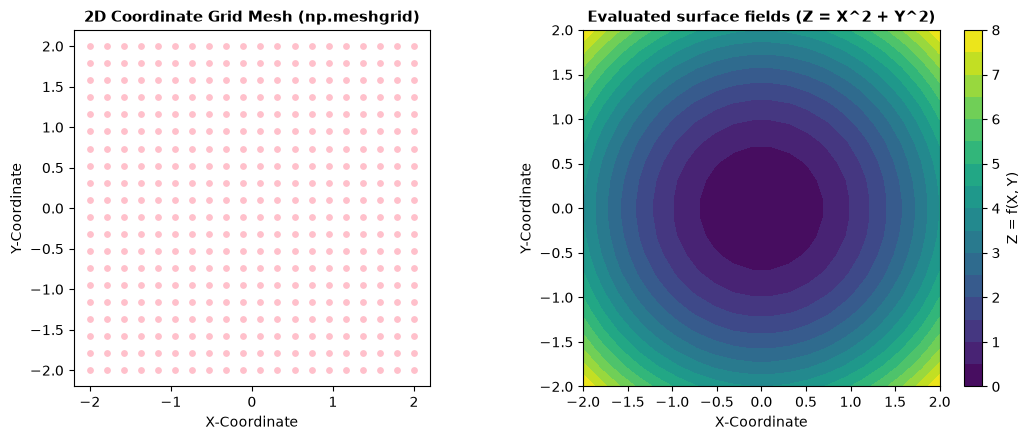

In [34]:
x_domain = np.linspace(-2, 2, 20)
y_domain = np.linspace(-2, 2, 20)

# print("X domain array:\n", x_domain)
# print("_" * 60)
# print("Y domain array:\n", y_domain)
# print("_" * 60)


# # Construct 2D coordinate matrices
X, Y = np.meshgrid(x_domain, y_domain)
# X is the row repeated for each x_domain value
# Y is the column repeated for each y_domain value
# Y is transposed compared to X

# # Evaluate 2D paraboloid surface Z = X^2 + Y^2
Z = X**2 + Y**2

# print(" Grid Coordinate output:")
# print(f"X Matrix {X.shape}")
# print(f"Y Matrix {Y.shape}")
# print(f"Z Matrix {Z.shape}")
print("Sample X matrix slice (first 3 x 3 block):\n", X[:3, :3])
print("Sample Y matrix slice (first 3 x 3 block):\n", Y[:3, :3])
# print("Sample Z matrix slice (first 3 x 3 block):\n", Z[:3, :3])
# print()

# Graphical visualization of the grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
# s is the size of the scatter plot markers
# sublot 1 : Scatter plot of the 2D coordinate grid
ax1.scatter(X, Y, c='pink', marker='o',s = 15)
ax1.set_title("2D Coordinate Grid Mesh (np.meshgrid)",fontsize=11,fontweight='bold')
ax1.set_xlabel("X-Coordinate")
ax1.set_ylabel("Y-Coordinate")
ax1.set_aspect('equal') # Parameter : 1. equal , 2. auto , ensures equal scaling of x and y axes

# subplot 2 : Contour plot of the 2D coordinate grid

# Parameters for the contour plot:
# cmap : Colormap used for the contour plot (e.g., 'viridis', 'plasma', 'inferno', 'magma')
contour =ax2.contourf(X, Y, Z, cmap='viridis', levels=15)

# ax2.contour is used on 2D data to create a 3D contour plot
# A contour plot represents the 3D surface on a 2D plane using filled contour levels
# contour levels are specified using the 'levels' parameter in ax2.contourf

fig.colorbar(contour, ax=ax2, label="Z = f(X, Y)")
ax2.set_title("Evaluated surface fields (Z = X^2 + Y^2)", fontsize=11, fontweight='bold')
ax2.set_xlabel("X-Coordinate")
ax2.set_ylabel("Y-Coordinate")
ax2.set_aspect('equal') # Ensures equal scaling of x and y axes

plt.tight_layout()
plt.show()



# Summary: NumPy Array Generation & Matplotlib Contour Visualization

---

## 1. Plotting Fundamentals (`plt.plot`)

* **Positional Parameters:** `plt.plot(x, y)` expects **$x$** (horizontal coordinates) as the first argument and **$y$** (vertical coordinates) as the second argument.
* **Length Constraint:** Both $x$ and $y$ must have matching lengths; omitting $x$ causes Matplotlib to default $x$ to integer indices `range(len(y))`.

---

## 2. Contour Plots (`ax.contour` vs. `ax.contourf`)

* **Definition:** A **contour line** (isoline) connects points of equal value in a 3D dataset $Z = f(X, Y)$ on a 2D plane—commonly used for topographic height, pressure, or intensity maps.
* **`ax.contour(X, Y, Z)`:** Draws thin **outline lines** representing equal-value boundaries.
* **`ax.contourf(X, Y, Z)`:** Fills the regions between contour lines with solid **colored gradients** (**f** stands for filled).

---

## 3. NumPy Array Generation Methods

| Function | Primary Parameter Input | Spacing Behavior | Key Real-Time Use Case |
| :--- | :--- | :--- | :--- |
| **`np.linspace`** | `start, stop, num` | Evenly spaced linearly over $[start, stop]$ | Sampling smooth mathematical curves & continuous time vectors |
| **`np.logspace`** | `start, stop, num` *(as exponents: $10^{start}$ to $10^{stop}$)* | Logarithmic (evenly spaced on power scale) | ML hyperparameter tuning (learning rates) & audio frequency analysis |
| **`np.geomspace`** | `start, stop, num` *(as actual direct values)* | Geometric progression (constant ratio between items) | Exponential growth models & non-uniform simulation meshes |
| **`np.arange`** | `start, stop, step` | Fixed step-based interval $[start, stop)$ | Loop iteration, array indexing, & histogram binning |
| **`np.meshgrid`** | `x_array, y_array` | 2D coordinate matrices paired across grid | Evaluating 3D surfaces $Z = f(X, Y)$ for contour plots & spatial heatmaps |